# Array Length Fidelity: Yelp `categories`

The Yelp dataset contains a `categories` field — a variable-length array of business category strings (e.g. `["Restaurants", "Pizza", "Fast Food"]`). Faithfully reproducing the distribution of array lengths is a key challenge for generative models on semi-structured data: a model that always generates arrays of length 4–5 will miss the long tail of highly specialised businesses with 10+ categories, and fail to capture the sparse end with 1–2 categories.

## Metric: Wasserstein Distance

We measure how well each model reproduces the real `categories` array length distribution using the **Wasserstein-1 distance** (Earth Mover's Distance).

Wasserstein measures the minimum "work" needed to reshape the synthetic length distribution into the real one, where work = mass × distance. Concretely, if the real distribution peaks at length 4 and a model shifts it to length 5, the distance is 1.0; a shift to length 8 gives 4.0.

We prefer Wasserstein over alternatives because:
- **Array lengths are ordered integers** — a prediction of 5 when the truth is 4 should be penalised less than a prediction of 10. Wasserstein respects this ordering; Total Variation distance (used for unordered categoricals) does not.
- **KL divergence** is undefined when the synthetic distribution assigns zero probability to lengths that appear in the real data, a common edge case. Wasserstein handles this gracefully.

Lower is better; 0 means the distributions are identical.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance

# --- Data paths ---
RESULTS = Path("../results/yelp")
REAL_PATH = RESULTS / "data" / "train.jsonl"
SYNTH_PATHS = {
    "Origami": RESULTS / "origami" / "samples" / "synthetic_1.jsonl",
    "TabDiff": RESULTS / "tabdiff" / "samples" / "synthetic_1.jsonl",
    "Tab.ARGN": RESULTS / "mostlyai" / "samples" / "synthetic_1.jsonl",
    "REalTabF.": RESULTS / "realtabformer" / "samples" / "synthetic_1.jsonl",
}

MODEL_ORDER = ["Origami", "TabDiff", "Tab.ARGN", "REalTabF."]


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]


def categories_alen(records):
    return np.array([len(r.get("categories") or []) for r in records])


real_records = load_jsonl(REAL_PATH)
real_lens = categories_alen(real_records)

synth_lens = {}
for name, path in SYNTH_PATHS.items():
    synth_lens[name] = categories_alen(load_jsonl(path))

print(f"Real: {len(real_records)} rows, mean alen = {real_lens.mean():.2f}")

Real: 135311 rows, mean alen = 4.45


In [2]:
print("Array length distribution")
print("  (Wasserstein: lower=better, 0=identical)")
print(f"{'Model':<14}  {'Mean':>6}  {'Std':>6}  {'Wasserstein':>12}")
print("-" * 46)
print(f"{'Real':<14}  {real_lens.mean():6.2f}  {real_lens.std():6.2f}")
for name in MODEL_ORDER:
    lens = synth_lens[name]
    w1 = wasserstein_distance(real_lens, lens)
    print(f"{name:<14}  {lens.mean():6.2f}  {lens.std():6.2f}  {w1:12.4f}")

Array length distribution
  (Wasserstein: lower=better, 0=identical)
Model             Mean     Std   Wasserstein
----------------------------------------------
Real              4.45    2.23
Origami           4.38    2.16        0.1692
TabDiff           4.94    2.15        0.5175
Tab.ARGN          4.74    1.97        0.4618
REalTabF.         3.98    1.95        0.4700


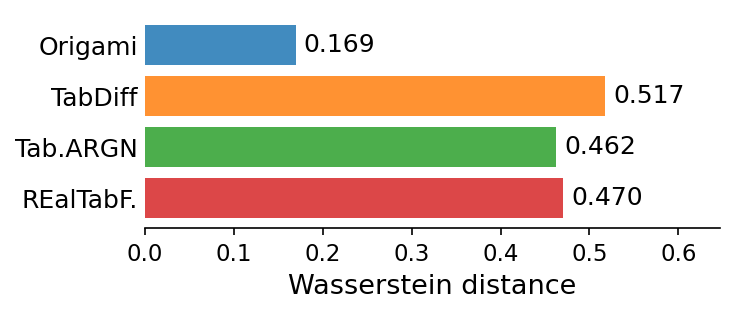

In [3]:
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
COLORS = {name: prop_cycle[i] for i, name in enumerate(MODEL_ORDER)}

w1_scores = {name: wasserstein_distance(real_lens, synth_lens[name]) for name in MODEL_ORDER}

fig, ax = plt.subplots(figsize=(5, 2.2), dpi=150)
bars = ax.barh(
    MODEL_ORDER[::-1],
    [w1_scores[m] for m in MODEL_ORDER[::-1]],
    color=[COLORS[m] for m in MODEL_ORDER[::-1]],
    alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=12)
ax.set_xlabel("Wasserstein distance", fontsize=13)
ax.set_xlim(0, max(w1_scores.values()) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=12)
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.savefig("yelp_array_length.pdf", bbox_inches="tight", dpi=300)
plt.savefig("yelp_array_length.png", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

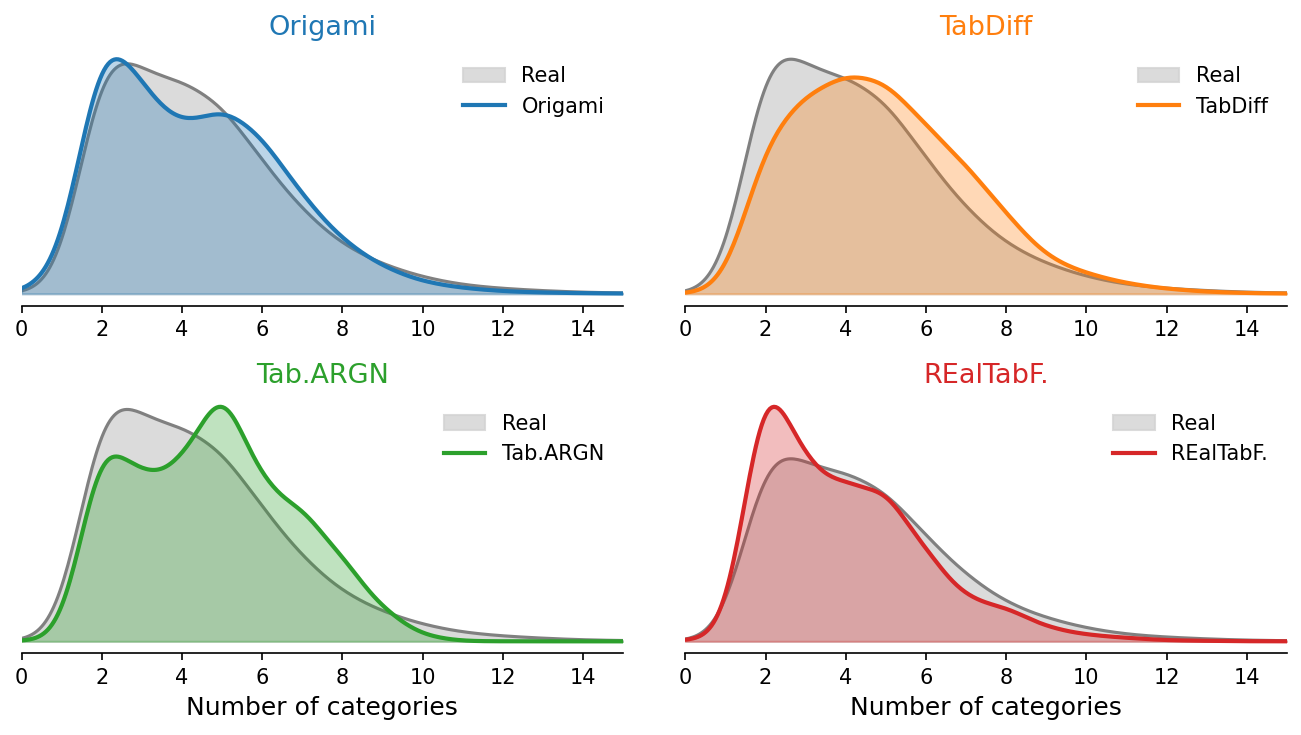

In [4]:
from scipy.stats import gaussian_kde

MAX_LEN = 15
xs = np.linspace(0, MAX_LEN, 300)
kde_real = gaussian_kde(real_lens, bw_method=0.3)

fig, axes = plt.subplots(2, 2, figsize=(9, 5), dpi=150)

for ax, name in zip(axes.flat, MODEL_ORDER):
    kde_synth = gaussian_kde(synth_lens[name], bw_method=0.3)

    ax.fill_between(xs, kde_real(xs), color="lightgrey", alpha=0.8, label="Real", zorder=1)
    ax.plot(xs, kde_real(xs), color="grey", lw=1.5, zorder=2)
    ax.fill_between(xs, kde_synth(xs), color=COLORS[name], alpha=0.3, zorder=3)
    ax.plot(xs, kde_synth(xs), color=COLORS[name], lw=2, label=name, zorder=4)

    ax.set_xlim(0, MAX_LEN)
    ax.set_yticks([])
    ax.set_title(name, fontsize=13, color=COLORS[name])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.legend(fontsize=10, frameon=False)

for ax in axes[1]:
    ax.set_xlabel("Number of categories", fontsize=12)

plt.tight_layout()
plt.savefig("yelp_array_length_dist.pdf", bbox_inches="tight", dpi=300)
plt.savefig("yelp_array_length_dist.png", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

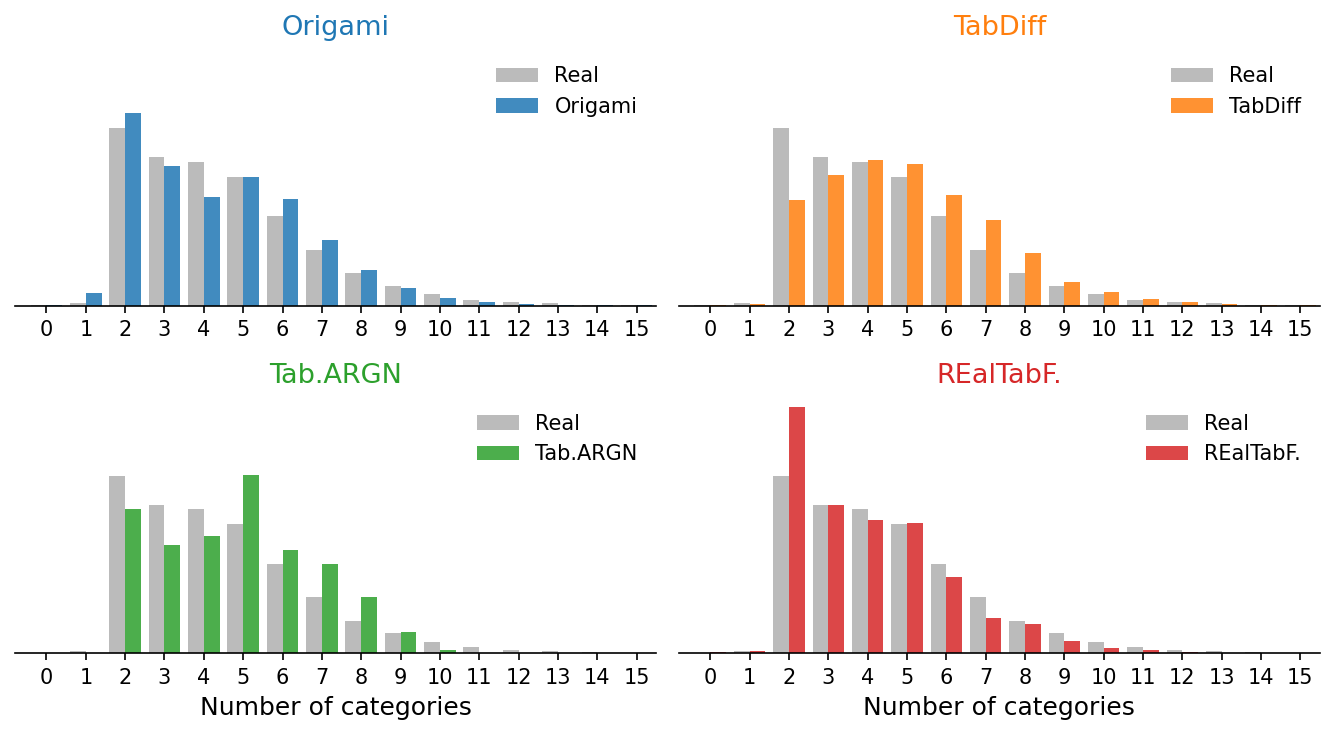

In [ ]:
MAX_LEN = 15
bins = np.arange(0, MAX_LEN + 2) - 0.5
xs = np.arange(0, MAX_LEN + 1)

real_pmf, _ = np.histogram(real_lens, bins=bins, density=True)

fig, axes = plt.subplots(2, 2, figsize=(9, 5), dpi=150, sharey=True)

for ax, name in zip(axes.flat, MODEL_ORDER):
    synth_pmf, _ = np.histogram(synth_lens[name], bins=bins, density=True)

    width = 0.4
    ax.bar(xs - width / 2, real_pmf, width=width, color="#aaa", label="Real")
    ax.bar(xs + width / 2, synth_pmf, width=width, color=COLORS[name], alpha=0.85, label=name)

    ax.set_xlim(-0.8, MAX_LEN + 0.5)
    ax.set_xticks(xs)
    ax.set_yticks([])
    ax.set_title(name, fontsize=13, color=COLORS[name])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.legend(fontsize=10, frameon=False)

for ax in axes[1]:
    ax.set_xlabel("Number of categories", fontsize=12)

plt.tight_layout()
plt.savefig("yelp_array_length_pmf.pdf", bbox_inches="tight", dpi=300)
plt.savefig("yelp_array_length_pmf.png", bbox_inches="tight", dpi=300, transparent=True)
plt.show()